### Author : Vaishnav Krishna P
#### Email : vyshnavkrishnap2020@gmai.com

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

### JSON to CSV Converter
- This script reads a JSON file named 'dev.json', converts its contents
into a tabular format using pandas, and saves it as 'dev.csv'. It handles nested JSON structures
by flattening them into columns, making the data easy to open and analyze in spreadsheet programs.
"""

In [2]:
import pandas as pd
import json

# Load JSON file
with open('dev.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

# Convert JSON to DataFrame
df = pd.json_normalize(data)

# Save as CSV
df.to_csv('dev.csv', index=False)

print("File converted to dev.csv successfully.")

File converted to dev.csv successfully.


### Database Record Visualization

This code counts the number of records for each unique database (using the 'db_id' column)
and plots the results as a bar chart for easy visualization.

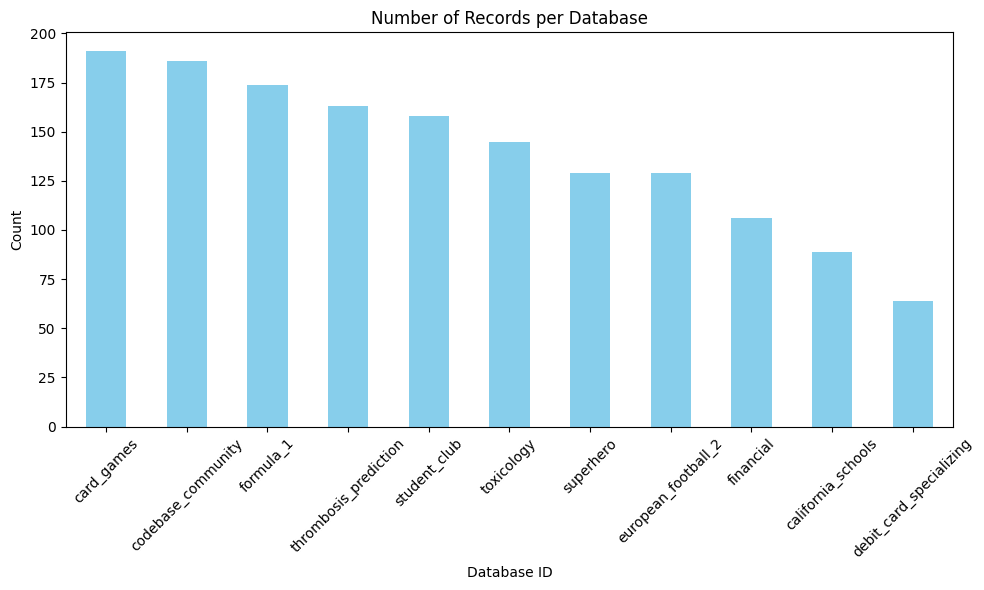

In [16]:
# Assuming df is your DataFrame
# Count the occurrences of each unique database
db_counts = df['db_id'].value_counts()

# Plot the results
plt.figure(figsize=(10,6))
db_counts.plot(kind='bar', color='skyblue')
plt.title("Number of Records per Database")
plt.xlabel("Database ID")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [17]:
 df['db_id'].value_counts()

,count
db_id,
card_games,191
codebase_community,186
formula_1,174
thrombosis_prediction,163
student_club,158
toxicology,145
superhero,129
european_football_2,129
financial,106


### Missing Value analysis

In [19]:
# Check for missing values in each column
missing_values = df.isnull().sum()

# Calculate percentage of missing values per column
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Combine into a single DataFrame for better visualization
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage
})

print("Missing Value Analysis:")
print(missing_df)


Missing Value Analysis:
             Missing Values  Percentage (%)
question_id               0             0.0
db_id                     0             0.0
question                  0             0.0
evidence                  0             0.0
SQL                       0             0.0
difficulty                0             0.0


### Questions by Difficulty per Database

This code analyzes the number of questions for each difficulty level
(simple, moderate, hard) in each database. It prints a summary table
and visualizes the data using a stacked bar chart.

Number of questions by difficulty per database:
difficulty               challenging  moderate  simple
db_id                                                 
california_schools                 5        30      54
card_games                        13        53     125
codebase_community                 5        30     151
debit_card_specializing            4        17      43
european_football_2               14        50      65
financial                          7        37      62
formula_1                         14        43     117
student_club                       9        48     101
superhero                         15        33      81
thrombosis_prediction             28        85      50
toxicology                        31        38      76


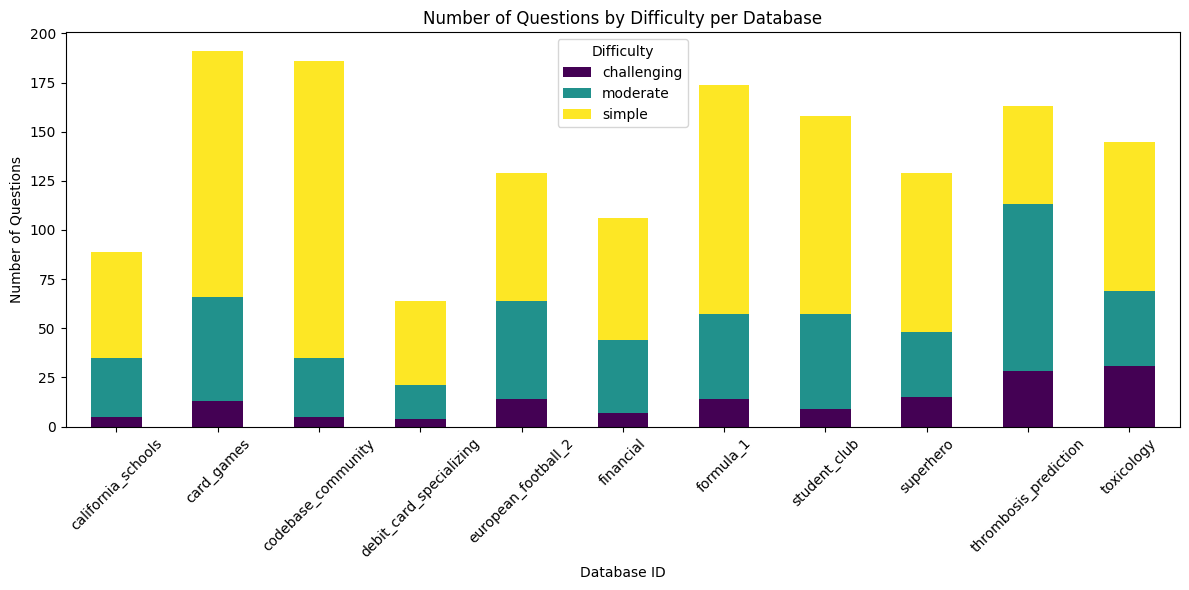

In [20]:
# Group by database and difficulty, then count the number of questions
difficulty_counts = df.groupby(['db_id', 'difficulty']).size().unstack(fill_value=0)

print("Number of questions by difficulty per database:")
print(difficulty_counts)

# Plot as a stacked bar chart
difficulty_counts.plot(kind='bar', stacked=True, figsize=(12,6), colormap='viridis')
plt.title("Number of Questions by Difficulty per Database")
plt.xlabel("Database ID")
plt.ylabel("Number of Questions")
plt.xticks(rotation=45)
plt.legend(title='Difficulty')
plt.tight_layout()
plt.show()


### Unique Question Sampler

This script selects a specified number of unique questions from each database
based on difficulty levels:
- 15 simple questions
- 7 moderate questions
- 3 challenging questions

The sampled questions are aggregated into a new CSV file named
'sampled_questions_unique.csv'.

In [29]:
import pandas as pd

# Define how many questions to sample per difficulty
sample_sizes = {
    'simple': 15,
    'moderate': 7,
    'challenging': 3
}

# Create an empty DataFrame to store sampled questions
sampled_df = pd.DataFrame()

# Loop over each database
for db in df['db_id'].unique():
    db_data = df[df['db_id'] == db]

    # Loop over each difficulty level
    for difficulty, n in sample_sizes.items():
        difficulty_data = db_data[db_data['difficulty'] == difficulty]

        # Sample 'n' unique questions without replacement
        sampled_questions = difficulty_data.sample(n=min(n, len(difficulty_data)), replace=False, random_state=42)

        # Append to the final DataFrame
        sampled_df = pd.concat([sampled_df, sampled_questions])

# Reset index
sampled_df = sampled_df.reset_index(drop=True)

# Save to CSV
sampled_df.to_csv('sampled_questions_unique.csv', index=False)

print("Unique sampled questions saved to 'sampled_questions_unique.csv'.")


Unique sampled questions saved to 'sampled_questions_unique.csv'.
